Chapter 3. Centrality, Power, and Bottlenecks

In [188]:
import networkx as net
from urllib.request import urlopen

In [189]:
import requests
response = requests.get("https://www.livejournal.com/misc/fdata.bml?user=valerois")
print(response.text)

# Note: Polite data miners cache on their end.  Impolite ones get banned.
> bagira
> angerona
> yankel
> yelya
> ponka
> marinka
> saper
> levinius
> monella
> irbisa
> innaplanetyanka
> hutshepsut
> skyg74
> samoleg
> actr
> gottfrid
> krimsky
> nelis
> ptfenix
> a_u
> e_f
> boctok
> karial
> wattson
> baryshnia
> ntl
> salamandrina_
> ant_fugue
> levik
> _milashka
> oonabond
> alinaf
> vollalol
> kitobow
> petitmari
> babushonok
> koniglio
> berryl
> sylphida
> graier
> drunk_cherry
> mamaracha
> doc_a
> 3eta
> togranada
> vorobeika
> mel_ny
> nicety
> elka_palka
> milady_winter
> lengo
> bengalia
> stalic
> asyatka
> kpoxa_e
> klaboo
> azbukivedi
> pavelrudnev
> vorodis
> ranja
> kirulya
> zlove
> charmel
> krolchatina
> glagolik
> _arizonadream_
> kessil
> pandausa
> sunnychka
> darwen
> sushile
> babkaezhka
> snusmoomrik
> bills_daughter
> cute_n_gorgeous
> fomina
> zoe_dorogaya
> ortivika
> kinoida
> xenia
> greenarine
> igmak
> elarbee
> viks_vaporub
> new_finder
> la_serafina
>

The function read_lj_friends(g,name) fetches a list of friends from the LiveJournal API, walks through the lines in the repsonse and creates edges.

In [190]:
def read_lj_friends(g,name):
    # fecth the friend-list from LiveJournal
    response = urlopen("https://www.livejournal.com/misc/fdata.bml?user="+name)
    
    #walk throough the line in the response and add each one as an edge in a network
    for line in response.readlines():
        line = line.decode('utf-8').strip()  # decode bytes -> str and strip whitespace
        #Comments in the response start with a '#'
        if line.startswith('#'): continue

        # the format is "< name" (incoming) or "> name" (oitgoing)
        # make sure that we don't have an empty line
        parts=line.split()

        if len(parts)==0: continue

        #add the edge to the network
        if parts[0]=='<':
            g.add_edge(parts[1],name)
        else:
            g.add_edge(name,parts[1])    

The Snowball sampling funcyion will take twp parameters - a network object into which new nodes and edges will be inserted, and name of the central node.

In [191]:
def snowball_sampling(g, center, max_depth=1, current_depth=0, taboo_list=[]):
    print(center, current_depth, max_depth, taboo_list)
    if current_depth == max_depth:
        # if we have reached the depth limit of the search, return.
        print('out of depth')
        return taboo_list
    else:
        taboo_list.append(center) # we shall never return to the same node

    read_lj_friends(g,center) # call LiveJournal API and get data for a node

    for node in g.neighbors(center):
        # iterate through all friends of the central nodd, call snowball_sampling recursively
        taboo_list = snowball_sampling(g, node, current_depth=current_depth+1, max_depth=max_depth, taboo_list=taboo_list)
        return taboo_list

In [192]:
g=net.Graph()
read_lj_friends(g,"valerois")
len(g)

296

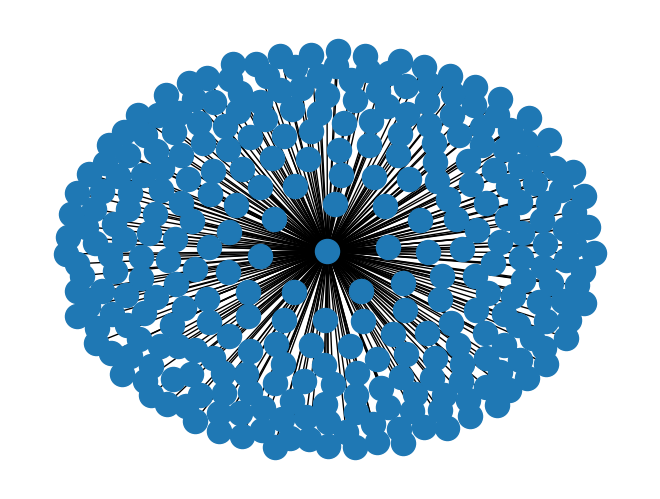

In [224]:
net.draw(g,with_labels=False)

In [194]:
g=net.Graph()
snowball_sampling(g,'valerois')

valerois 0 1 []
bagira 1 1 ['valerois']
out of depth


['valerois']

Save data using a Pajek format -- a simple text based format that has been a lingua franca for exchanging network data.

In [195]:
net.write_pajek(g,'lj_friends.net')

A node degree is simply the number of connections that a node has.  

Degree Centrality

Degree is returned as a Python map -- a set of name value pairs linking node names to the degree value.

In [196]:
g=net.read_pajek('lj_friends.net')

In [197]:
len(g)

296

In [198]:
# compute degree
deg=net.degree(g)

In [199]:
deg

MultiDegreeView({'valerois': 295, 'bagira': 1, 'angerona': 1, 'yankel': 1, 'yelya': 1, 'ponka': 1, 'marinka': 1, 'saper': 1, 'levinius': 1, 'monella': 1, 'irbisa': 1, 'innaplanetyanka': 1, 'hutshepsut': 1, 'skyg74': 1, 'samoleg': 1, 'actr': 1, 'gottfrid': 1, 'krimsky': 1, 'nelis': 1, 'ptfenix': 1, 'a_u': 1, 'e_f': 1, 'boctok': 1, 'karial': 1, 'wattson': 1, 'baryshnia': 1, 'ntl': 1, 'salamandrina_': 1, 'ant_fugue': 1, 'levik': 1, '_milashka': 1, 'oonabond': 1, 'alinaf': 1, 'vollalol': 1, 'kitobow': 1, 'petitmari': 1, 'babushonok': 1, 'koniglio': 1, 'berryl': 1, 'sylphida': 1, 'graier': 1, 'drunk_cherry': 1, 'mamaracha': 1, 'doc_a': 1, '3eta': 1, 'togranada': 1, 'vorobeika': 1, 'mel_ny': 1, 'nicety': 1, 'elka_palka': 1, 'milady_winter': 1, 'lengo': 1, 'bengalia': 1, 'stalic': 1, 'asyatka': 1, 'kpoxa_e': 1, 'klaboo': 1, 'azbukivedi': 1, 'pavelrudnev': 1, 'vorodis': 1, 'ranja': 1, 'kirulya': 1, 'zlove': 1, 'charmel': 1, 'krolchatina': 1, 'glagolik': 1, '_arizonadream_': 1, 'kessil': 1, 'pa

In [200]:
degree_values = dict(deg).values()
min(degree_values)

1

In [201]:
deg['valerois']

295

In [202]:
#This function returns a sorted degree list -- useful for celebrity spotting
def sorted_map(map):
    ms = sorted(dict(map).items(), key=lambda kv: (-kv[1], kv[0]))
    return ms

In [203]:
max(degree_values)

295

In [204]:
ds=sorted_map(deg)

In [205]:
ds[0:9]

[('valerois', 295),
 ('3eta', 1),
 ('_arizonadream_', 1),
 ('_milashka', 1),
 ('a_dyukov', 1),
 ('a_u', 1),
 ('aallaa_korg', 1),
 ('ackeldama', 1),
 ('actr', 1)]

In [206]:
import matplotlib.pyplot as plot

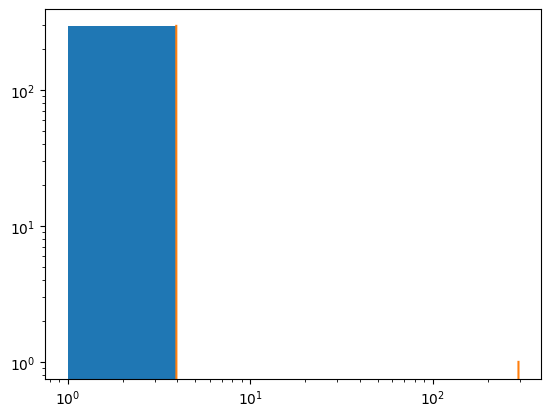

In [207]:
h=plot.hist(degree_values,100)
plot.loglog(h[1][1:],h[0])

(array([295.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([  1.  ,   3.94,   6.88,   9.82,  12.76,  15.7 ,  18.64,  21.58,
         24.52,  27.46,  30.4 ,  33.34,  36.28,  39.22,  42.16,  45.1 ,
         48.04,  50.98,  53.92,  56.86,  59.8 ,  62.74,  65.68,  68.62,
         71.56,  74.5 ,  77.44,  80.38,  83.32,  86.26,  89.2 ,  92.14,
         95.08,  98.02, 100.96

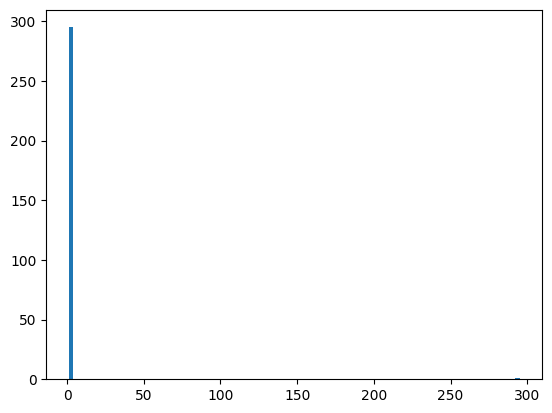

In [226]:
plot.hist(degree_values,100)

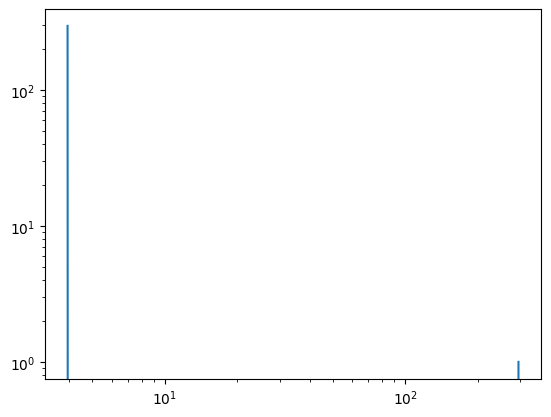

In [227]:
plot.loglog(h[1][1:],h[0])

Return a new graph object that conatains the network with pendant and isolated nodes removed

In [213]:
def trim_degrees(g,degree=1):
    g2=g.copy()
    d=net.degree(g2)
    for n in list(g2.nodes()):
        if d[n]<=degree: 
            g2.remove_node(n)
    return g2

In [214]:
core=trim_degrees(g)

In [215]:
len(core)

1

In [219]:
core2=trim_degrees(g,degree=2)

In [220]:
len(core2)

1

In [221]:
core3=trim_degrees(g,degree=3)

In [222]:
len(core3)

1

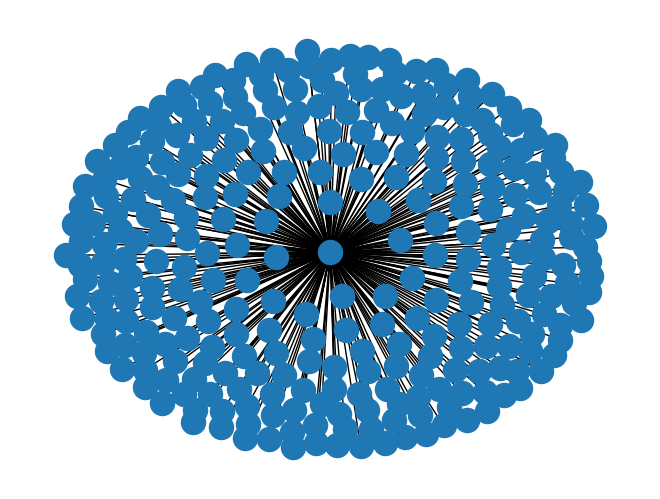

In [225]:
net.draw(g,with_labels=False)